<a href="https://colab.research.google.com/github/diseasemodeling/MIE_525_625/blob/main/Lectures/4_MLP_heads/4d_tick_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification of `tick_status`

Standalone notebook (uses the raw panel directly, not any cached rolling-
window data from the Neural CDE notebook).

- **Target**: `tick_status` -- 0 = no reports, 1 = recorded, 2 = established
  (ordinal, 3 classes).
- **Independent variables only**: temperature, precipitation, land cover,
  forest-edge metrics, RUCC, and population density.
- **Same-year (contemporaneous) prediction**: 2020 features predict 2020
  `tick_status`, etc. -- no windowing or lag.
- **Independent samples**: every (county, year) row with a real survey
  result is pooled and cross-validated as an i.i.d. sample -- years are not
  treated as a time series for this task.
- **2023 is held out entirely** as a genuine validation set
- Any year with **no** surveyed counties at all is dropped outright; rows
  still missing the target or any required feature are dropped individually.

A second analysis then checks whether the trained model has enough capacity
to catch counties in the very first year their status flips from
**recorded (1) to established (2)** -- a proxy for whether a genuine
one-year-ahead early-warning forecast is plausible.


## 0. Setup

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV
import copy
import itertools
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split



pd.set_option("display.max_columns", 100)
np.random.seed(42)
print("Ready.")

Ready.


## 1. Load the raw panel + tick status + case-definition shift indicators

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Example: Reading a CSV from the Colab sample_data directory
# If your CSV is in a different location, adjust the path accordingly.
csv_path = '/content/drive/MyDrive/Colab Notebooks/MIE525_625_DeepLearning/lyme_sentinel_ers5'
#df_colab_csv = pd.read_csv(csv_path)
#display(df_colab_csv.head())

In [ ]:
from pathlib import Path
#DATA_DIR = Path.cwd() / "data"
#CHECKPOINT_DIR = Path.cwd() / "checkpoints"
#CHECKPOINT_DIR = Path.cwd() / "rrdi_panel_package/scripts/checkpoints"
#DATA_DIR = Path.cwd() / "rrdi_panel_package/data"

#panel_data = pd.read_csv(DATA_DIR / "LymeSentinel_env_dataset_2001_2024.csv", low_memory=False)
panel_data = pd.read_csv(Path(csv_path) / "LymeSentinel_env_dataset_2001_2024.csv", low_memory=False)
panel = panel_data.copy()
panel["GEOID"] = panel["GEOID"].astype(str).str.zfill(5)
panel["YEAR"] = panel["YEAR"].astype(int)
print(f"Loaded env panel: {panel.shape}")

def clean_geoid(df, col="GEOID"):
    df = df.copy()
    raw = df[col].astype(str).str.replace('"', "").str.strip()
    numeric = pd.to_numeric(raw, errors="coerce")
    df = df.loc[numeric.notna()].copy()
    df[col] = numeric.loc[numeric.notna()].astype(int).astype(str).str.zfill(5)
    return df

# Tick surveillance status -- sparse survey years only.
target_raw = clean_geoid(pd.read_csv(Path(csv_path) / "d40f1ac4-1873-489c-a23e-a7c3ecb54619.csv", low_memory=False))
SCAP_YEARS = [2016, 2018, 2019, 2020, 2023] #[1996, 2016, 2018, 2019, 2020, 2023]
tick_rows = []
for y in SCAP_YEARS:
    col = f"SCAP_{y}"
    if col in target_raw.columns:
        sub = target_raw[["GEOID", col]].rename(columns={col: "tick_status"})
        sub["YEAR"] = y
        tick_rows.append(sub)
tick_status_by_year = pd.concat(tick_rows, ignore_index=True)

panel = panel.merge(tick_status_by_year, on=["GEOID", "YEAR"], how="left")
print(f"Tick status merged. Non-null tick_status rows: {panel['tick_status'].notna().sum():,}")
print("tick_status value counts:")
print(panel["tick_status"].value_counts(dropna=False).sort_index())

Loaded env panel: (75288, 37)
Tick status merged. Non-null tick_status rows: 15,540
tick_status value counts:
tick_status
Established     4994
No records      7686
Reported        2860
NaN            59748
Name: count, dtype: int64


## 2. Feature columns

In [ ]:
CONTINUOUS_COLS = [
    "elev_mean_m", "elev_std_m",
    "slope_mean_deg", "slope_std_deg",
    "lc_barren", "lc_cultivated", "lc_developed", "lc_forest",
    "lc_herbaceous", "lc_shrubland", "lc_water", "lc_wetlands",
    "rucc_code", "pop_density_km2",
    "forest_edge_len", "edge_density",
    "forest_dev_edge", "forest_dev_edge_density",
    "temp_annual", #"temp_winter", "temp_spring", "temp_summer", "temp_fall",
    "precip_annual",# "precip_winter", "precip_spring", "precip_summer", "precip_fall",
]
CONTINUOUS_COLS = [c for c in CONTINUOUS_COLS if c in panel.columns]
print(f"{len(CONTINUOUS_COLS)} continuous columns available")

20 continuous columns available


## 3. Build the modeling dataset

In [ ]:
TICK_CLASSES = [0, 1, 2]  # 0 = no reports, 1 = recorded, 2 = established
TICK_CLASS_NAMES = {0: "No records", 1: "Reported", 2: "Established"}
TICK_VAL_YEAR = 2023

TEMP_COLS = [c for c in CONTINUOUS_COLS if c.startswith("temp")]
PRECIP_COLS = [c for c in CONTINUOUS_COLS if c.startswith("precip_")]
LANDCOVER_COLS = [c for c in CONTINUOUS_COLS if c.startswith("lc_")]
FOREST_COLS = [c for c in CONTINUOUS_COLS if c in
               ["forest_edge_len", "edge_density", "forest_dev_edge", "forest_dev_edge_density"]]
RUCC_DENSITY_COLS = [c for c in CONTINUOUS_COLS if c in ["rucc_code", "pop_density_km2"]]

TICK_INDEP_COLS = TEMP_COLS + PRECIP_COLS + LANDCOVER_COLS + FOREST_COLS + RUCC_DENSITY_COLS
print(f"Independent variables ({len(TICK_INDEP_COLS)}): {TICK_INDEP_COLS}")

# --- Build the modeling frame from the RAW panel (real 0/1/2 tick_status, not one-hot) ---
tick_raw = panel[["GEOID", "YEAR", "tick_status"] + TICK_INDEP_COLS].copy()

all_years_in_panel = sorted(tick_raw["YEAR"].unique())
n_before_target = len(tick_raw)
tick_raw = tick_raw.dropna(subset=["tick_status"])
years_with_target = sorted(tick_raw["YEAR"].unique())
discarded_years_no_target = sorted(set(all_years_in_panel) - set(years_with_target))
print(f"Years with ANY tick_status survey: {years_with_target}")
print(f"Years discarded entirely (no survey at all): {discarded_years_no_target}")
print(f"Rows dropped for missing target: {n_before_target - len(tick_raw)}")

n_before_feat = len(tick_raw)
tick_model_df = tick_raw.dropna(subset=TICK_INDEP_COLS).copy()

# Map string labels to integers
reverse_tick_class_names = {v: k for k, v in TICK_CLASS_NAMES.items()}
tick_model_df["tick_status"] = tick_model_df["tick_status"].map(reverse_tick_class_names)
tick_model_df["tick_status"] = tick_model_df["tick_status"].astype(int)

print(f"Rows dropped for missing >=1 required feature: {n_before_feat - len(tick_model_df)}")

years_final = sorted(tick_model_df["YEAR"].unique())
fully_discarded = sorted(set(years_with_target) - set(years_final))
print(f"\nYears remaining after feature-completeness filter: {years_final}")
if fully_discarded:
    print(f"(Years that had a survey but zero usable feature rows -- discarded: {fully_discarded})")

print(f"\nFinal modeling rows: {len(tick_model_df)}")
print("\nClass counts per year:")
print(pd.crosstab(tick_model_df["YEAR"], tick_model_df["tick_status"]))

Independent variables (16): ['temp_annual', 'precip_annual', 'lc_barren', 'lc_cultivated', 'lc_developed', 'lc_forest', 'lc_herbaceous', 'lc_shrubland', 'lc_water', 'lc_wetlands', 'forest_edge_len', 'edge_density', 'forest_dev_edge', 'forest_dev_edge_density', 'rucc_code', 'pop_density_km2']
Years with ANY tick_status survey: [np.int64(2016), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2023)]
Years discarded entirely (no survey at all): [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2017), np.int64(2021), np.int64(2022), np.int64(2024)]
Rows dropped for missing target: 59748
Rows dropped for missing >=1 required feature: 711

Years remaining after feature-completeness filter: [np.int64(2016), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2023)]

Final modeling ro

## 4. Train / cross-validation split — 2023 held out as validation

In [ ]:
tick_train_pool = tick_model_df[tick_model_df["YEAR"] != TICK_VAL_YEAR].reset_index(drop=True)
tick_val_df = tick_model_df[tick_model_df["YEAR"] == TICK_VAL_YEAR].reset_index(drop=True)
# Random stratified 80-20 split with clean index resets
#tick_train_pool, tick_val_df = train_test_split(tick_model_df, test_size=0.2, random_state=42)
#tick_train_pool, tick_val_df = tick_train_pool.reset_index(drop=True), tick_val_df.reset_index(drop=True)

assert len(tick_val_df) > 0, f"No rows for validation year {TICK_VAL_YEAR} -- check it's in years_final above."
print(f"Train pool (all years except {TICK_VAL_YEAR}): {len(tick_train_pool)} rows, "
      f"years {sorted(tick_train_pool['YEAR'].unique())}")
print(f"Validation ({TICK_VAL_YEAR}): {len(tick_val_df)} rows")

tick_X_train = tick_train_pool[TICK_INDEP_COLS].values
tick_y_train = tick_train_pool["tick_status"].values
tick_years_train = tick_train_pool["YEAR"].values

tick_X_val = tick_val_df[TICK_INDEP_COLS].values
tick_y_val = tick_val_df["tick_status"].values


Train pool (all years except 2023): 11803 rows, years [np.int64(2016), np.int64(2018), np.int64(2019), np.int64(2020)]
Validation (2023): 3026 rows


# Random forests

In [ ]:
# Set seeds for reproducibility
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# --- Define the MLP Architecture ---
class TickMLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, n_classes, dropout):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# --- Class Weights for CrossEntropyLoss ---
def class_weights_for(y, n_classes):
    counts = np.bincount(y, minlength=n_classes)
    w = len(y) / (n_classes * np.maximum(counts, 1))
    return torch.tensor(w, dtype=torch.float32)

# --- Mini-Batch Training Loop ---
def train_mlp(X_tr, y_tr, X_te, y_te, config, n_classes):
    """
    Trains the MLP using mini-batches and tracks validation loss for early stopping.
    """
    # 1. Setup DataLoaders for mini-batching
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)
    y_te_t = torch.tensor(y_te, dtype=torch.long)

    train_dataset = TensorDataset(X_tr_t, y_tr_t)
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)

    # 2. Initialize model and optimization
    model = TickMLP(X_tr.shape[1], config['hidden_sizes'], n_classes, config['dropout'])
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    criterion = nn.CrossEntropyLoss(weight=class_weights_for(y_tr, n_classes))

    # 3. Track metrics
    best_test_loss = float("inf")
    best_state = None
    epochs_since_improvement = 0
    patience = 30
    max_epochs = 300

    for epoch in range(1, max_epochs + 1):
        # Training Phase (Mini-batch loop)
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

        # Validation Phase (Full evaluation evaluation batch size can also be used if needed)
        model.eval()
        with torch.no_grad():
            test_loss = criterion(model(X_te_t), y_te_t).item()

        # Early Stopping check
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1

        if epochs_since_improvement >= patience:
            break
        if epoch % 100 == 0:
          print(f"Epoch {epoch}/{max_epochs} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss:.4f}")
    return best_test_loss, best_state, epoch

# --- Hyperparameter Tuning Setup ---
def tune_hyperparameters(X, y, n_classes, n_trials=10):
    """
    Executes a Random Search over a parameter grid.
    """
    # Define hyperparameter search space
    param_grid = {
        'hidden_sizes': [(128, 128, 64, 64), (64, 64)],
        'dropout': [0.2, 0.3],
        'lr': [1e-4, 1e-3],
        'weight_decay': [1e-5, 1e-4],
        'batch_size': [32, 64, 128]
    }

    # Split into train/validation sets for tuning evaluation
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE)

    scaler = StandardScaler().fit(X_tr)
    X_tr_scaled = scaler.transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    # Generate all unique combinations and sample trials
    keys, values = zip(*param_grid.items())
    all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    sampled_trials = random.sample(all_combinations, min(n_trials, len(all_combinations)))

    best_overall_loss = float("inf")
    best_config = None
    best_model_weights = None

    print(f"Starting tuning over {len(sampled_trials)} sampled hyperparameter sets...")
    for idx, config in enumerate(sampled_trials, 1):
        test_loss, model_weights, stop_epoch = train_mlp(X_tr_scaled, y_tr, X_te_scaled, y_te, config, n_classes)
        print(f"Trial {idx}/{len(sampled_trials)} -> Loss: {test_loss:.4f} | Config: {config} | Epochs: {stop_epoch}")

        if test_loss < best_overall_loss:
            best_overall_loss = test_loss
            best_config = config
            best_model_weights = model_weights

    print(f"\nTuning Complete! Best Loss: {best_overall_loss:.4f}")
    print(f"Best Configuration: {best_config}")

    # Reconstruct the optimized final model framework
    final_model = TickMLP(X.shape[1], best_config['hidden_sizes'], n_classes, best_config['dropout'])
    final_model.load_state_dict(best_model_weights)

    return final_model, scaler, best_config

# --- Inference Sklearn-like Wrapper ---
#note: a Sklearn is used because for this project we were evaluating various ML models includeing RF, XGBoost, that use sklearn.
# using this wrapper standaridzes the rest of the code: to handle below
  # for pytorch we need to convert to tensors and then back to numpy arrays.
  # here additionally normlization (zscaler) is wrapped into this, so we can directly call
  # with wrapper can directly do model.predict(X_data_raw)
class TorchMLPClassifier:
    def __init__(self, model, scaler):
        self.model = model.eval()
        self.scaler = scaler

    def predict(self, X_raw):
        X_scaled = self.scaler.transform(X_raw)
        with torch.no_grad():
            logits = self.model(torch.tensor(X_scaled, dtype=torch.float32))
            return logits.argmax(dim=1).numpy()

In [ ]:
num_classes=3
optimized_model, final_scaler, best_params = tune_hyperparameters(
    tick_X_train, tick_y_train, n_classes=num_classes, n_trials=1
)

# Wrap the finalized layout for straightforward `.predict()` mapping downstream
nn_mlp = TorchMLPClassifier(optimized_model, final_scaler)

Starting tuning over 1 sampled hyperparameter sets...
Epoch 100/300 | Train Loss: 0.7810 | Test Loss: 0.6763
Epoch 200/300 | Train Loss: 0.4414 | Test Loss: 0.6087
Epoch 300/300 | Train Loss: 0.4636 | Test Loss: 0.5519
Trial 1/1 -> Loss: 0.5519 | Config: {'hidden_sizes': (128, 128, 64, 64), 'dropout': 0.2, 'lr': 0.0001, 'weight_decay': 1e-05, 'batch_size': 128} | Epochs: 300

Tuning Complete! Best Loss: 0.5519
Best Configuration: {'hidden_sizes': (128, 128, 64, 64), 'dropout': 0.2, 'lr': 0.0001, 'weight_decay': 1e-05, 'batch_size': 128}


## 6. Precision / recall by class, by year

In [ ]:
def per_year_precision_recall(y_true, y_pred, years_arr, years_to_report, label):
    rows = []
    for yr in years_to_report:
        mask = years_arr == yr
        p, r, f, support = precision_recall_fscore_support(
            y_true[mask], y_pred[mask], labels=TICK_CLASSES, zero_division=0)
        for i, cls in enumerate(TICK_CLASSES):
            rows.append({"Set": label, "Year": yr, "Class": f"{cls} ({TICK_CLASS_NAMES[cls]})",
                         "Precision": round(p[i], 3), "Recall": round(r[i], 3), "F1 score": round(f[i], 3), "N": int(support[i])})
    return pd.DataFrame(rows)


# --- Train Set Predictions ---
tick_train_pred = nn_mlp.predict(tick_X_train)
tick_train_table = per_year_precision_recall(
    tick_y_train, tick_train_pred, tick_years_train, sorted(np.unique(tick_years_train)), "Train (in-sample)")

# --- Validation Set (Held-out) Predictions ---
tick_val_pred = nn_mlp.predict(tick_X_val)
tick_val_table = per_year_precision_recall(
    tick_y_val, tick_val_pred, np.full(len(tick_y_val), TICK_VAL_YEAR), [TICK_VAL_YEAR], "Validation (held-out)")

# --- Combine all tables ---
#tick_results_table = pd.concat([tick_train_table, tick_cv_table, tick_val_table], ignore_index=True)
tick_results_table = pd.concat([tick_train_table, tick_val_table], ignore_index=True)

print("Precision / recall by class, by year (Train and Validation):")
tick_results_table


Precision / recall by class, by year (Train and Validation):


,Set,Year,Class,Precision,Recall,F1 score,N
0,Train (in-sample),2016,0 (No records),0.945,0.724,0.820,1547
1,Train (in-sample),2016,1 (Reported),0.490,0.859,0.624,562
2,Train (in-sample),2016,2 (Established),0.821,0.760,0.790,839
3,Train (in-sample),2018,0 (No records),0.961,0.742,0.838,1404
4,Train (in-sample),2018,1 (Reported),0.524,0.833,0.643,605
5,Train (in-sample),2018,2 (Established),0.813,0.781,0.796,944
6,Train (in-sample),2019,0 (No records),0.959,0.741,0.836,1404
7,Train (in-sample),2019,1 (Reported),0.528,0.879,0.660,577
8,Train (in-sample),2019,2 (Established),0.855,0.798,0.825,963
9,Train (in-sample),2020,0 (No records),0.940,0.761,0.841,1412


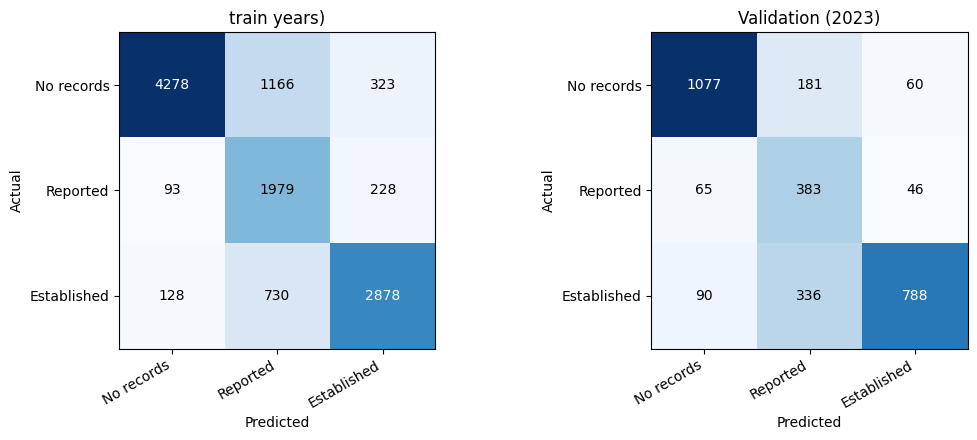

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (y_true, y_pred, title) in zip(
        axes,
        [(tick_y_train, tick_train_pred, "train years)"),
         (tick_y_val, tick_val_pred, f"Validation ({TICK_VAL_YEAR})")]):
    cm = confusion_matrix(y_true, y_pred, labels=TICK_CLASSES)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels([TICK_CLASS_NAMES[c] for c in TICK_CLASSES], rotation=30, ha="right")
    ax.set_yticklabels([TICK_CLASS_NAMES[c] for c in TICK_CLASSES])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

Calculating SHAP values...
Generating Overall SHAP Mean Absolute Summary Plot...


/tmp/ipykernel_5352/4151122377.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


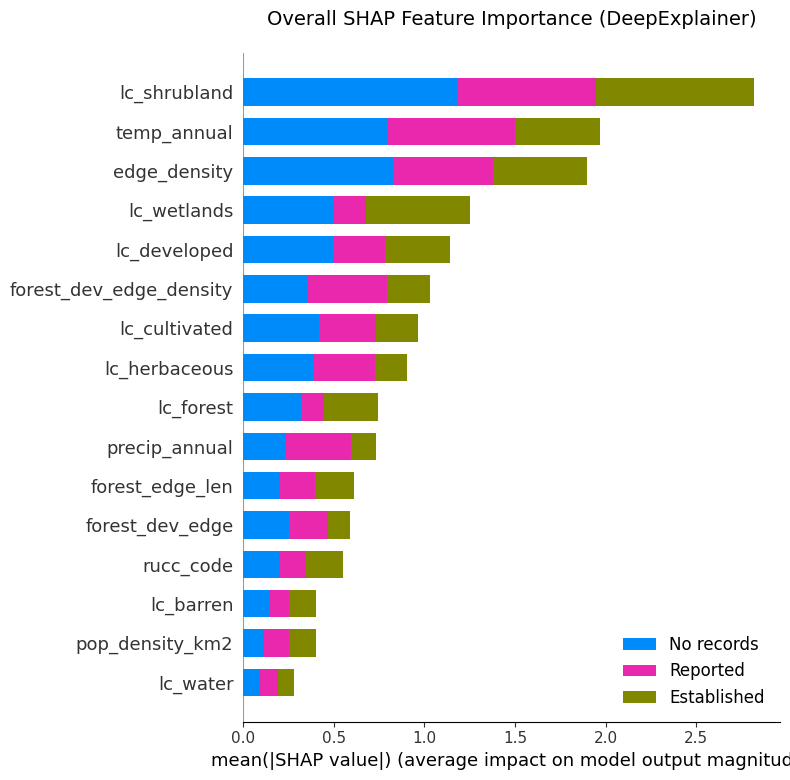

In [ ]:
import numpy as np
import torch
import shap
import matplotlib.pyplot as plt

# 1. Sample a representative background dataset
scaled_X_train = final_scaler.transform(tick_X_train)
background_idx = np.random.choice(scaled_X_train.shape[0], 100, replace=False)
background_data = torch.tensor(scaled_X_train[background_idx], dtype=torch.float32)

# 2. Initialize the DeepExplainer
explainer = shap.DeepExplainer(optimized_model, background_data)

# 3. Sample a subset of the validation set to explain
scaled_X_val = final_scaler.transform(tick_X_val)
val_idx = np.random.choice(scaled_X_val.shape[0], 100, replace=False)
sample_X_val_tensor = torch.tensor(scaled_X_val[val_idx], dtype=torch.float32)

# 4. Calculate SHAP values
print("Calculating SHAP values...")
shap_values = explainer.shap_values(sample_X_val_tensor)

# 5. Format SHAP values specifically for the multi-class Mean SHAP summary plot
# summary_plot expects a list of 2D arrays [samples, features] for multi-class overlaying
if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    # Convert [samples, features, classes] -> list of 3 arrays of shape [samples, features]
    plot_shap_values = [shap_values[:, :, i] for i in range(3)]
else:
    plot_shap_values = shap_values

# =====================================================================
# PART A: OVERALL MEAN SHAP SUMMARY PLOT (All Classes)
# =====================================================================
print("Generating Overall SHAP Mean Absolute Summary Plot...")
plt.figure(figsize=(10, 6))

shap.summary_plot(
    plot_shap_values,
    features=sample_X_val_tensor.numpy(),
    feature_names=TICK_INDEP_COLS,
    class_names=TICK_CLASS_NAMES,
    show=False
)

plt.title("Overall SHAP Feature Importance (DeepExplainer)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()



Generating SHAP beeswarm plot for No records...


/tmp/ipykernel_5352/753858684.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


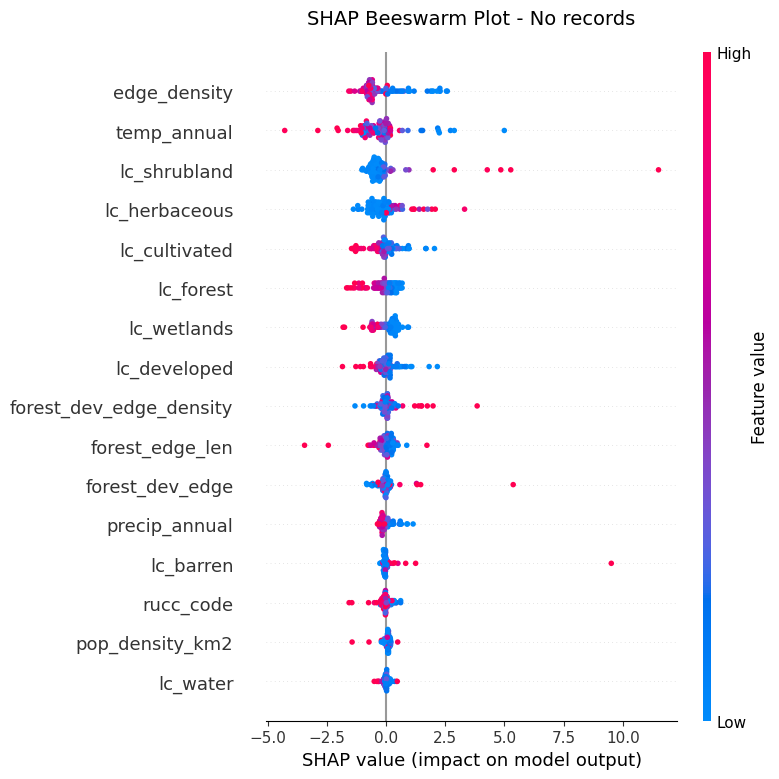

Generating SHAP beeswarm plot for Reported...


/tmp/ipykernel_5352/753858684.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


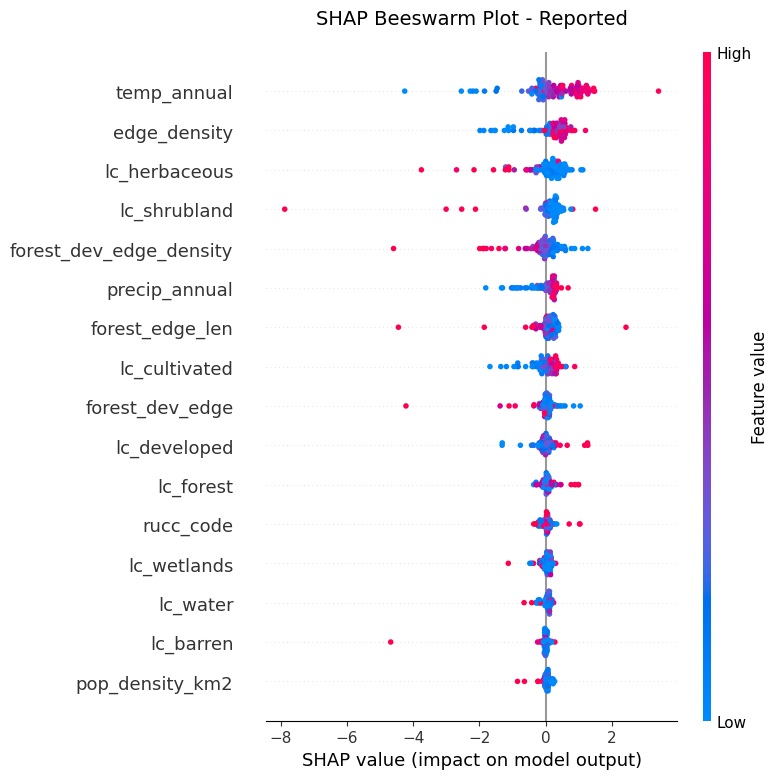

Generating SHAP beeswarm plot for Established...


/tmp/ipykernel_5352/753858684.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


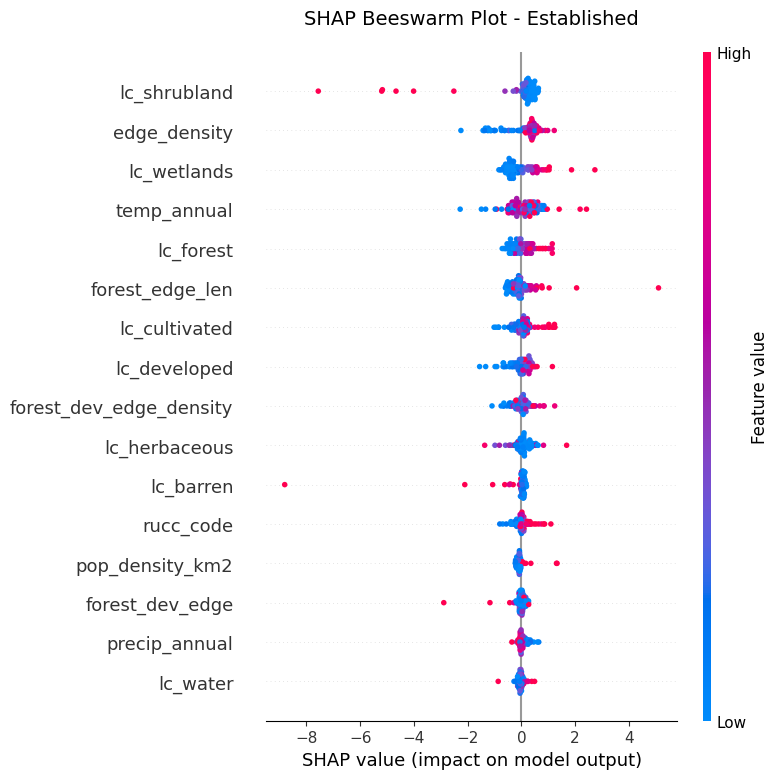

In [ ]:
# =====================================================================
# PART B: BEESWARM PLOTS FOR EACH INDIVIDUAL CLASS
# =====================================================================
for class_idx in range(3):
    print(f"Generating SHAP beeswarm plot for {TICK_CLASS_NAMES[class_idx]}...")

    # Extract the correct 2D slice for the current class beeswarm
    if isinstance(shap_values, list):
        class_shap_values = shap_values[class_idx]
    elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
        class_shap_values = shap_values[:, :, class_idx]
    else:
        raise ValueError("Unexpected shape_values format. Ensure your model outputs 3 classes.")

    plt.figure(figsize=(10, 6))

    # "dot" plot_type renders the beeswarm visualization
    shap.summary_plot(
        class_shap_values,
        features=sample_X_val_tensor.numpy(),
        feature_names=TICK_INDEP_COLS,
        plot_type="dot",
        show=False
    )

    plt.title(f"SHAP Beeswarm Plot - {TICK_CLASS_NAMES[class_idx]}", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
